# Grayscale Image → Pixel Array

Read a 76×62 grayscale image, inspect pixel values, and build a flat array ready to be passed into a CUDA kernel for RGB conversion.

In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [7]:
IMAGE_PATH = "GeneratedImage_grayscale.png"

img = Image.open(IMAGE_PATH).convert("L")   # "L" = 8-bit grayscale
width, height = img.size

print(f"Mode   : {img.mode}")
print(f"Width  : {width}  px")
print(f"Height : {height} px")
print(f"Total pixels: {width * height}")

Mode   : L
Width  : 1388  px
Height : 1133 px
Total pixels: 1572604


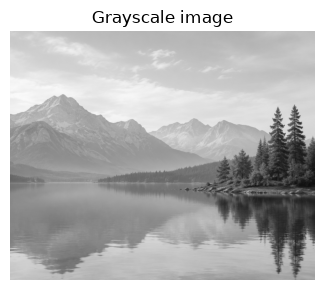

In [8]:
plt.figure(figsize=(4, 3))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale image")
plt.axis("off")
plt.tight_layout()
plt.show()

## Pixel values as a 2-D array
`numpy` stores each pixel as a `uint8` (0–255). Shape is **(height, width)** — row-major, same layout CUDA expects.

In [9]:
# Shape: (height, width) = (62, 76), dtype uint8
pixels_2d = np.array(img)

print(f"Array shape : {pixels_2d.shape}")   # (62, 76)
print(f"dtype       : {pixels_2d.dtype}")
print(f"\nFirst 5 rows (each row = one line of pixels):")
print(pixels_2d[:5])

Array shape : (1133, 1388)
dtype       : uint8

First 5 rows (each row = one line of pixels):
[[204 207 207 ... 191 191 190]
 [206 206 207 ... 190 191 190]
 [208 207 208 ... 190 190 190]
 [207 207 208 ... 190 189 189]
 [207 208 209 ... 190 189 190]]


## Save pixels to a text file
Writes every pixel value in row-major order, one row per line, space-separated.

In [10]:
OUTPUT_TXT = "input_pixels.txt"

with open(OUTPUT_TXT, "w") as f:
    for row in pixels_2d:
        f.write(" ".join(str(v) for v in row) + "\n")

print(f"Saved to {OUTPUT_TXT}  ({height} rows × {width} cols)")

Saved to input_pixels.txt  (1133 rows × 1388 cols)
